In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [2]:
# Load source datasets and shapefile layers
fl_nri = pd.read_csv("Project4_Data/NRI_Table_CensusTracts_Florida.csv")
fl_svi = pd.read_csv("Project4_Data/Florida.csv")

la_nri = pd.read_csv("Project4_Data/NRI_Table_CensusTracts_Louisiana.csv")
la_svi = pd.read_csv("Project4_Data/Louisiana.csv")

tracts = gpd.read_file("Project4_Data/student_shape_file")
tracts = tracts.replace(-9999, np.nan)

# Load data dictionary for field descriptions
nri_dictionary = pd.read_csv("Project4_Data/NRIDataDictionary(in).csv")

# Create common merge key for county-level joins
fl_nri["STCNTY"] = fl_nri["STCOFIPS"]
la_nri["STCNTY"] = la_nri["STCOFIPS"]

# Merge NRI and SVI data for each state
fl_complete_data = pd.merge(
    fl_nri, fl_svi,
    on="STCNTY",
    suffixes=("", "_right"))

la_complete_data = pd.merge(
    la_nri, la_svi,
    on="STCNTY",
    suffixes=("", "_right"))

# Identify numeric columns for missing-value treatment
num_cols = fl_complete_data.select_dtypes(
    include=["int64", "float64"]).columns

# Replace missing numeric values with column medians
fl_complete_data[num_cols] = fl_complete_data[num_cols].fillna(
    fl_complete_data[num_cols].median())

la_complete_data[num_cols] = la_complete_data[num_cols].fillna(
    la_complete_data[num_cols].median())

# Remove duplicate tract records and create clean copies
fl_complete_data = fl_complete_data.drop_duplicates(
    subset="TRACTFIPS").copy()

la_complete_data = la_complete_data.drop_duplicates(
    subset="TRACTFIPS").copy()

# Display descriptions for variables used in the analysis
print(
    nri_dictionary[
        nri_dictionary["Field Name"].str.contains(
            "CFLD_RISKS|CFLD_EXPT|CFLD_AFREQ|CFLD_HLRP|""LNDS_RISKS|LNDS_EXPT|LNDS_AFREQ|LNDS_HLRP|"
            "HRCN_RISKS|HRCN_EXPT|HRCN_AFREQ|HRCN_HLRP|""SOVI_SCORE|RESL_SCORE")][["Field Name", "Field Alias"]])

MemoryError: Unable to allocate 4.00 GiB for an array with shape (396, 1355364) and data type float64

In [3]:
tracts_clean = tracts.set_crs(epsg = 4326, inplace = True, allow_override = True) #Sets coordinate system for shapefile

tracts_clean = tracts_clean.to_crs(epsg = 4326)#Transforms to new CRS

tracts_clean = tracts_clean.replace(-9999, np.nan) #Replaces all the unwanted -9999 values with NaN

tracts_clean.crs = "EPSG:3857" #Changes CRS

tracts_clean = tracts_clean.to_crs(epsg=4326) #Converts to degrees to match limits

tracts_clean = tracts_clean.to_crs("ESRI:102003") #Sets to standard projection for contiguous US maps

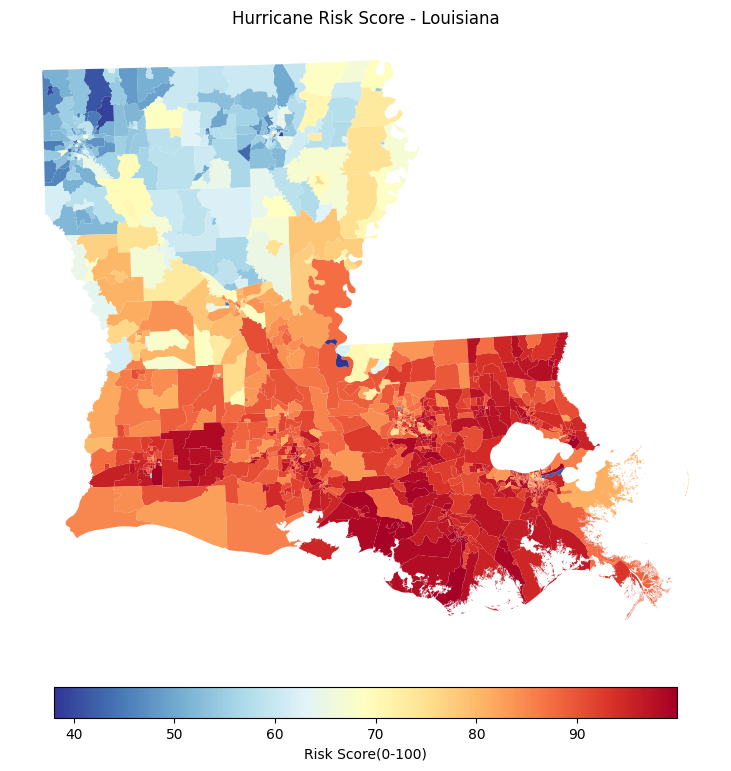

In [5]:
state_name = 'Louisiana'  #State variable

state_map = tracts_clean[tracts_clean["STATE"].str.lower() == state_name.lower()] #Filters for data for given state

fig, ax = plt.subplots(1, 1, figsize=(12, 10)) #Creates plot

#Adds state choropleth data to plot
state_map.plot(column = 'HRCN_RISKS', ax = ax, legend = True, linewidth = 0.0, cmap = 'RdYlBu_r', legend_kwds = {'label': 'Risk Score(0-100)', 'orientation': 'horizontal', 'shrink':0.67, 'pad':0.05}, missing_kwds = {'color': 'lightgrey', 'label':'No Data'})
ax.set_title('Hurricane Risk Score - Louisiana')
ax.set_axis_off()

plt.show()

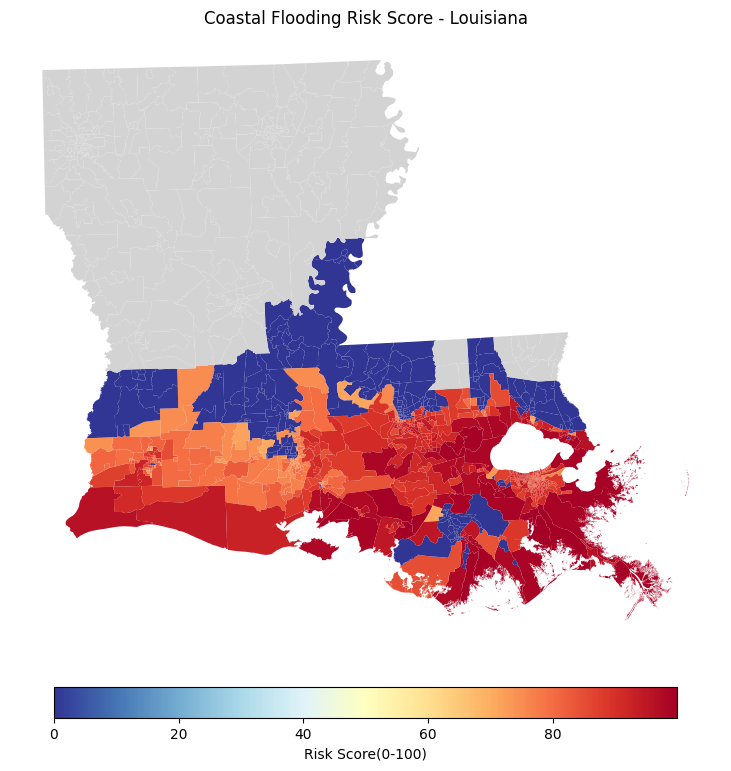

In [7]:
state_name = 'Louisiana'  #State variable

state_map = tracts_clean[tracts_clean["STATE"].str.lower() == state_name.lower()] #Filters for data for given state

fig, ax = plt.subplots(1, 1, figsize=(12, 10)) #Creates plot

#Adds state choropleth data to plot
state_map.plot(column = 'CFLD_RISKS', ax = ax, legend = True, linewidth = 0.0, cmap = 'RdYlBu_r', legend_kwds = {'label': 'Risk Score(0-100)', 'orientation': 'horizontal', 'shrink':0.67, 'pad':0.05}, missing_kwds = {'color': 'lightgrey', 'label':'No Data'})
ax.set_title('Coastal Flooding Risk Score - Louisiana')
ax.set_axis_off()

plt.show()

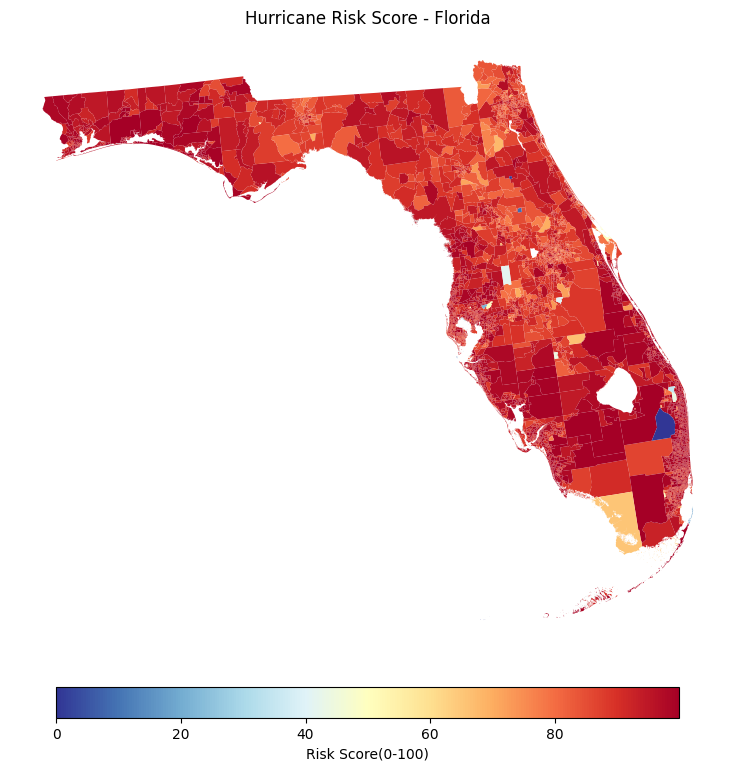

In [8]:
state_name = 'Florida'  #State variable

state_map = tracts_clean[tracts_clean["STATE"].str.lower() == state_name.lower()] #Filters for data for given state

fig, ax = plt.subplots(1, 1, figsize=(12, 10)) #Creates plot

#Adds state choropleth data to plot
state_map.plot(column = 'HRCN_RISKS', ax = ax, legend = True, linewidth = 0.0, cmap = 'RdYlBu_r', legend_kwds = {'label': 'Risk Score(0-100)', 'orientation': 'horizontal', 'shrink':0.67, 'pad':0.05}, missing_kwds = {'color': 'lightgrey', 'label':'No Data'})
ax.set_title('Hurricane Risk Score - Florida')
ax.set_axis_off()

plt.show()

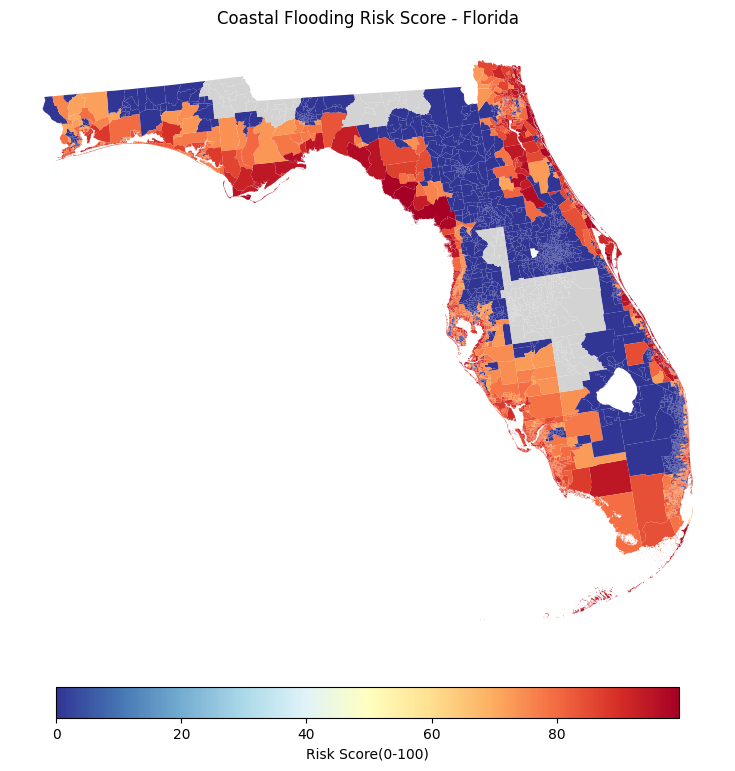

In [10]:
state_name = 'Florida'  #State variable

state_map = tracts_clean[tracts_clean["STATE"].str.lower() == state_name.lower()] #Filters for data for given state

fig, ax = plt.subplots(1, 1, figsize=(12, 10)) #Creates plot

#Adds state choropleth data to plot
state_map.plot(column = 'CFLD_RISKS', ax = ax, legend = True, linewidth = 0.0, cmap = 'RdYlBu_r', legend_kwds = {'label': 'Risk Score(0-100)', 'orientation': 'horizontal', 'shrink':0.67, 'pad':0.05}, missing_kwds = {'color': 'lightgrey', 'label':'No Data'})
ax.set_title('Coastal Flooding Risk Score - Florida')
ax.set_axis_off()

plt.show()